# Módulo 2 Implementación de un modelo de deep learning
## Daniel Jimenez Zuñiga A01748460

## Introducción

En este proyecto se aborda el problema de clasificación de escenas naturales a partir de imágenes. El objetivo es que, dada una imagen, el modelo pueda asignarla a una de las 6 categorías del dataset Intel: buildings, forest, glacier, mountain, sea, street. Este tipo de problema es relevante porque aparece en muchos casos reales: organización automática de fotos, sistemas de recomendación de contenido visual, apoyo en visión por computador y, en general, como ejercicio para diseñar y entrenar redes convolucionales.

La intención del proyecto no es solo lograr una buena exactitud, sino aplicar correctamente el flujo de deep learning visto en el módulo: preparar datos, construir un modelo base, analizar su desempeño, mejorarlo con técnicas de regularización/arquitectura y, finalmente, probarlo con imágenes nuevas.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [14]:
from tensorflow.keras import mixed_precision
tf.config.list_physical_devices('GPU')   # should show at least one GPU

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Datos

Para el experimento se utilizó el dataset “Intel Image Classification” obtenido de Kaggle. La versión utilizada viene organizada en carpetas:

seg_train/seg_train/... → imágenes de entrenamiento

seg_test/seg_test/... → imágenes de prueba

seg_pred/seg_pred/... → imágenes de predicción

Y tienen una subcarpeta correspondiente a cada clase: buildings, forest, glacier, mountain, sea, street.

EL DATASET DE DATOS SE PUEDE OBTENER MEDIANTE ESTE LINK: https://www.kaggle.com/datasets/puneet6060/intel-image-classification?resource=download

No se subió a Github porque es muy pesado

Preprocesamiento aplicado:

Se redimensionaron todas las imágenes a 224 × 224 píxeles para que el modelo reciba tensores del mismo tamaño y se escalaron los píxeles a rango [0,1] con layers.Rescaling

Además, para el modelo mejorado (segundo modelo), se uso data augmentation, como giros horizontales, pequeñas rotaciones y zoom (RandomFlip, RandomRotation, RandomZoom). Esto ayuda a que el modelo generalice mejor y no quede sesgado solamente a las imágenes exactas del training dataset.

In [15]:
import os
from tensorflow import keras

# base folder
DATA_DIR = "Dataset Intel"

TRAIN_DIR = os.path.join(DATA_DIR, "seg_train", "seg_train")
TEST_DIR  = os.path.join(DATA_DIR, "seg_test", "seg_test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)


Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Desarrollo del Modelo

Como primer paso se construyó un modelo convolucional sencillo con Keras:

entrada: 224x224x3

Rescaling(1./255)

bloque Conv2D(32) + MaxPooling

bloque Conv2D(64) + MaxPooling

bloque Conv2D(128) + MaxPooling

Flatten

Dense(128, relu)

salida Dense(6, softmax)

Se entrenó durante 10 épocas con Adam(1e-3) y sparse_categorical_crossentropy.
Los resultados mostraron que el modelo sí aprende (la accuracy de entrenamiento sube), pero a partir de cierto punto la pérdida de validación empieza a subir y la accuracy de validación a bajar, lo que indica sobreajuste (overfitting). Esto se ve en las primeras dos gráficas: el modelo llega alrededor de 0.70 de accuracy de validación en las mejores épocas, pero luego cae.

Este modelo base sirve como referencia para poder justificar cambios posteriores.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [18]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=IMG_SIZE + (3,)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


/Users/danielj./miniconda3/envs/modulo2_deeplearning/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 178ms/step - accuracy: 0.5527 - loss: 1.4219 - val_accuracy: 0.6276 - val_loss: 0.9593
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 255ms/step - accuracy: 0.6782 - loss: 0.8817 - val_accuracy: 0.7142 - val_loss: 0.8022
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.6504 - loss: 0.9787 - val_accuracy: 0.6625 - val_loss: 0.8684
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 88s 250ms/step - accuracy: 0.7356 - loss: 0.7484 - val_accuracy: 0.6728 - val_loss: 1.0548
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 89s 253ms/step - accuracy: 0.7637 - loss: 0.7944 - val_accuracy: 0.6985 - val_loss: 1.1787
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 89s 252ms/step - accuracy: 0.7809 - loss: 1.0392 - val_accuracy: 0.7014 - val_loss: 2.2528
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 249ms/step - accuracy: 0.7422 - loss: 2.3657 - val_accuracy: 0.6354 - val_loss: 4.4088
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 245ms/step - accuracy: 0.7277 - loss: 3.4551 - val

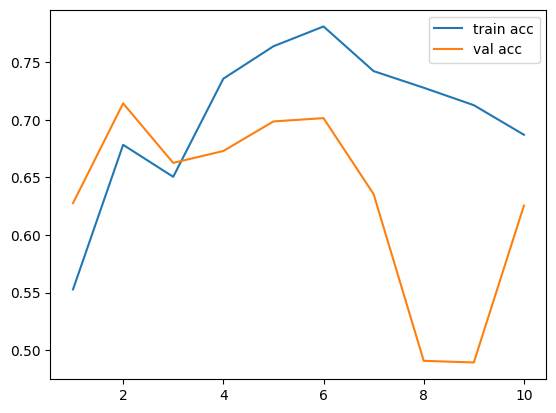

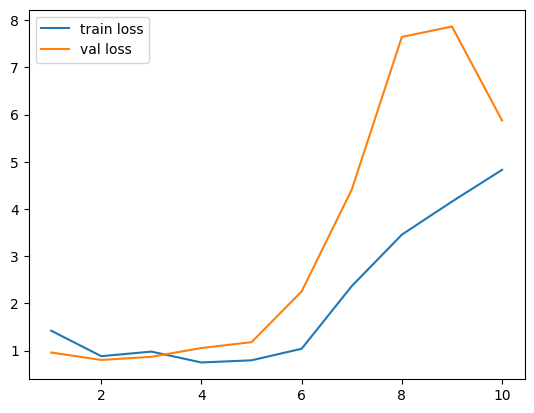

In [20]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc)+1)

plt.figure()
plt.plot(epochs, acc, label="train acc")
plt.plot(epochs, val_acc, label="val acc")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, loss, label="train loss")
plt.plot(epochs, val_loss, label="val loss")
plt.legend()
plt.show()


## Ajuste del Modelo

Para mejorar el desempeño y reducir el sobreajuste se hicieron estos cambios:

1. Data augmentation al inicio del modelo:

- RandomFlip("horizontal")

- RandomRotation(0.1)

- RandomZoom(0.1)
Esto genera variaciones de las imágenes de entrada y hace que el modelo vea ejemplos “nuevos” en cada época.

- BatchNormalization después de cada capa convolucional, para estabilizar el entrenamiento.

2. Dropout:

- 0.4 después del último bloque conv

- 0.5 después de la capa densa de 256 neuronas
Esto reduce la probabilidad de que el modelo memorice el train.

3. Otros cambios:

- Capa densa más grande (256 neuronas) para aumentar capacidad.

- Learning rate más bajo (Adam(1e-4)) para hacer el aprendizaje más suave.

- EarlyStopping con patience=5 para detener entrenamiento si la validación deja de mejorar.


Después de estos cambios la arquitectura de la red fue la siguiente:

Input (224,224,3)

Augment → Rescaling

Conv(32) + BN + MaxPool

Conv(64) + BN + MaxPool

Conv(128) + BN + MaxPool + Dropout(0.4)

Flatten

Dense(256, relu) + Dropout(0.5)

Dense(6, softmax)

Al entrenar este modelo, la accuracy se mantiene más estable y la validación ya no cae tan fuerte como en el baseline. Además, el test accuracy sobre el conjunto seg_test quedó alrededor de 0.688 (≈69%), lo que es mejor que lo que se veía en el primer modelo.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.4)(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

better_model = keras.Model(inputs, outputs)

better_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history2 = better_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 213s 600ms/step - accuracy: 0.4994 - loss: 6.9705 - val_accuracy: 0.2060 - val_loss: 12.5251
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 208s 591ms/step - accuracy: 0.5707 - loss: 6.4572 - val_accuracy: 0.6372 - val_loss: 5.4479
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 208s 591ms/step - accuracy: 0.5794 - loss: 6.4171 - val_accuracy: 0.6418 - val_loss: 5.5489
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 215s 612ms/step - accuracy: 0.5914 - loss: 6.3080 - val_accuracy: 0.6144 - val_loss: 6.0517
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 216s 614ms/step - accuracy: 0.6011 - loss: 6.2101 - val_accuracy: 0.6618 - val_loss: 5.2530
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 220s 625ms/step - accuracy: 0.6036 - loss: 6.1947 - val_accuracy: 0.6358 - val_loss: 5.7321
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 215s 612ms/step - accuracy: 0.6160 - loss: 6.0062 - val_accuracy: 0.6589 - val_loss: 5.3235
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 214s 608ms/step - accuracy: 0.6288 

In [23]:
os.makedirs("models", exist_ok=True)
better_model.save("models/intel_cnn.keras")
print("Modelo guardado en models/intel_cnn.keras")

Modelo guardado en models/intel_cnn.keras


## Resultados

Modelo base: llegó a ~0.70 de accuracy de validación en las mejores épocas, pero empezó a sobreajustar (val_loss subió rápido).

Modelo mejorado: obtuvo una accuracy de prueba (test) de ≈ 0.6887 sobre 3000 imágenes de 6 clases. Esto muestra que el modelo generaliza razonablemente bien al conjunto que no vio.

Las gráficas de entrenamiento del modelo mejorado muestran una ligera variación de la accuracy de validación entre ~0.62 y ~0.70, lo cual es esperable considerando que hay augmentations y que las clases del dataset no son perfectamente lineales.

El loss en validación es más estable que en el primer intento y el early stopping ayudó a no seguir entrenando cuando ya no había mejora.

Estos resultados son suficientes para la práctica y permiten comparar claramente “modelo base” vs “modelo mejorado”.

In [24]:
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(AUTOTUNE)

test_loss, test_acc = better_model.evaluate(test_ds)
print("Test accuracy:", test_acc)

Found 3000 files belonging to 6 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.6887 - loss: 4.9290
Test accuracy: 0.6886666417121887


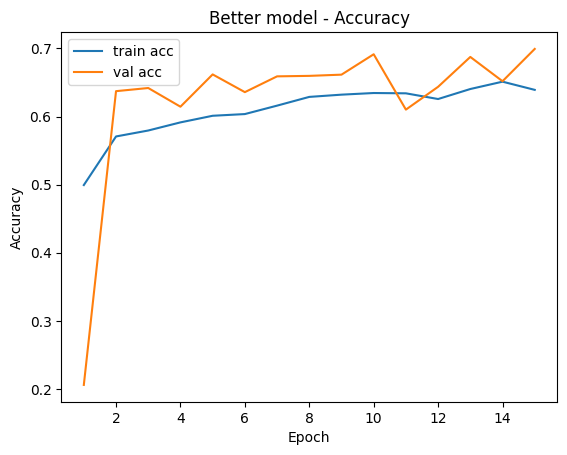

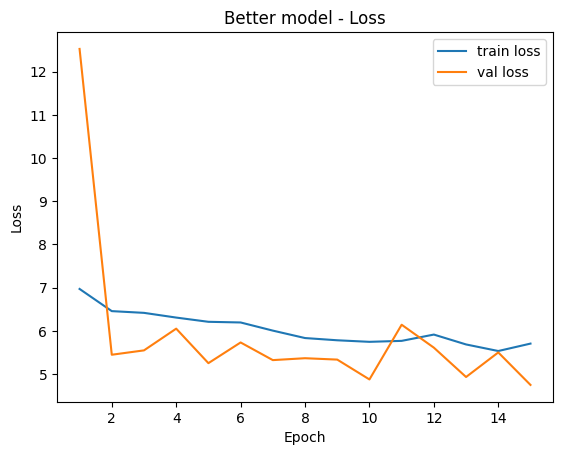

In [25]:
acc = history2.history["accuracy"]
val_acc = history2.history["val_accuracy"]
loss = history2.history["loss"]
val_loss = history2.history["val_loss"]
epochs = range(1, len(acc) + 1)

# Accuracy
plt.figure()
plt.plot(epochs, acc, label="train acc")
plt.plot(epochs, val_acc, label="val acc")
plt.title("Better model - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(epochs, loss, label="train loss")
plt.plot(epochs, val_loss, label="val loss")
plt.title("Better model - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Conclusiones

1. El modelo convolucional básico sí aprende la tarea de clasificación de escenas, pero sin regularización empieza a sobreajustar después de pocas épocas.

2. Las técnicas de mejora aplicadas (augmentation, batch normalization, dropout y menor learning rate) sí tuvieron efecto, logrando un modelo más estable y con mejor desempeño en el set de prueba.

3. El valor de ~0.69 de accuracy en test no es perfecto, pero es coherente con:

- el tamaño de las imágenes (224x224),

- la arquitectura relativamente pequeña,

- El hecho de que se entrenó desde cero y no con transfer learning.

4. Para mejorar todavía más, se podrían probar:

- modelos pre-entrenados (MobileNetV2, EfficientNetB0) congelando las primeras capas,

- más épocas con early stopping

- Balanceo de clases si alguna categoría tuviera menos ejemplos.


## Aplicación

Se creó una función de prueba que recibe rutas de imágenes, las redimensiona a 224×224 y las pasa al modelo para mostrar la clase predicha y su confianza. Se probó con 1–2 imágenes de varias carpetas (sea, forest, glacier, buildings, street) y el modelo clasificó dentro de las 6 clases. El modelo entrenado se guardó en models/intel_cnn.keras, así que puede cargarse después con keras.models.load_model(...) y usar la misma función sin volver a entrenar.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


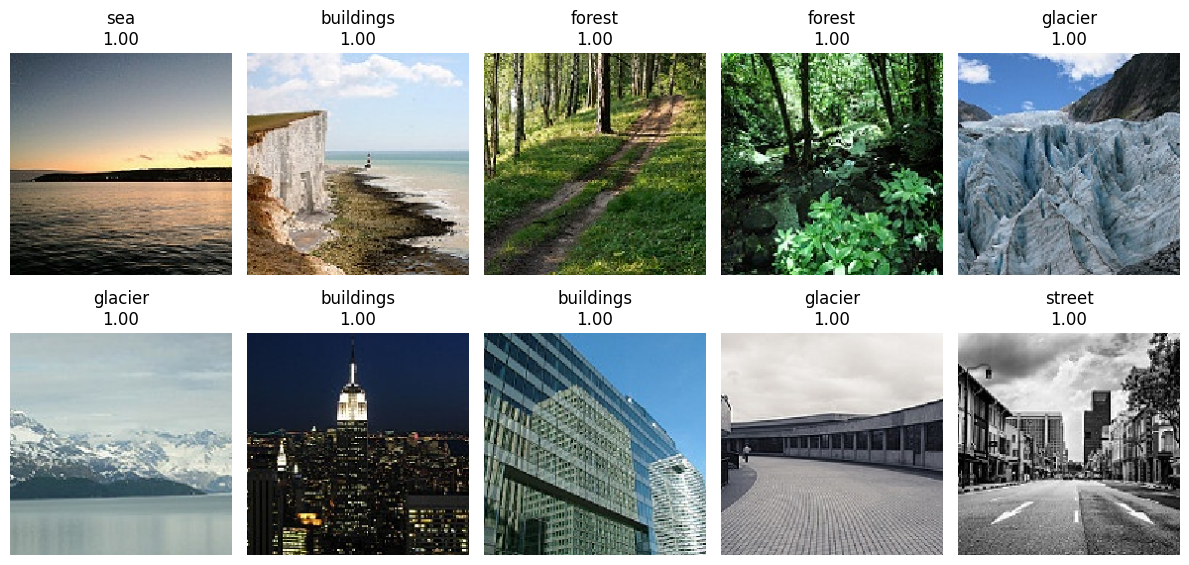

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.utils import load_img, img_to_array

loaded_model = keras.models.load_model("models/intel_cnn.keras")

def predict_images(model, img_paths, img_size=IMG_SIZE, class_names=None):
    batch = []
    for p in img_paths:
        img = load_img(p, target_size=img_size)
        arr = img_to_array(img)           # <-- sin /255
        batch.append(arr)
    batch = np.stack(batch, axis=0)

    preds = model.predict(batch)

    plt.figure(figsize=(12, 6))
    for i, p in enumerate(img_paths):
        pred = preds[i]
        idx = np.argmax(pred)
        label = class_names[idx] if class_names else idx
        score = float(pred[idx])

        plt.subplot(2, (len(img_paths)+1)//2, i+1)
        img = load_img(p, target_size=img_size)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{label}\n{score:.2f}")
    plt.tight_layout()
    plt.show()

# sample de varias clases
classes_to_use = ["sea", "forest", "glacier", "buildings", "street"]
sample_paths = []
for cls in classes_to_use:
    cls_dir = os.path.join(TEST_DIR, cls)
    imgs = [f for f in os.listdir(cls_dir) if not f.startswith(".")]
    sample_paths.extend([os.path.join(cls_dir, f) for f in imgs[:2]])

predict_images(loaded_model, sample_paths, IMG_SIZE, class_names)
